In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

I0000 00:00:1788932145.942018   80574 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788932145.994540   80574 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788932148.558417   80574 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
x, y = make_circles(n_samples=100, noise=0.1, random_state=1)

In [3]:
print(x)
print(y)

[[-0.63640493 -0.36870191]
 [-0.24465976 -0.73659196]
 [-0.46597138 -1.06687743]
 [-0.70999784 -0.40841948]
 [ 0.70232238 -0.51730147]
 [-0.49776571  0.76955129]
 [-0.31914906 -0.84899624]
 [-0.57839322 -0.49081236]
 [-0.53350227  0.58056527]
 [-0.24733259  0.73011595]
 [ 0.41030774 -0.73075986]
 [ 0.17181003 -0.92504802]
 [ 0.65917045  0.62120588]
 [ 0.87625577  0.12510879]
 [ 0.81946243 -0.01347859]
 [-0.47960986 -0.7880243 ]
 [-0.90187751 -0.70895455]
 [ 0.74827659 -0.55976747]
 [-0.74875324 -0.37153443]
 [ 0.23161178  1.01205842]
 [ 0.81387506  0.22821311]
 [-0.92169575  0.20310719]
 [ 0.74650434 -0.35861224]
 [ 0.01330079  0.68169193]
 [-0.72651409  0.58630948]
 [-0.33930852 -1.0080984 ]
 [ 0.49009938 -0.62509577]
 [-0.9539309  -0.33410313]
 [ 0.6927241  -0.59576417]
 [ 0.003546   -0.9098264 ]
 [-0.35077763  0.82536558]
 [ 0.94798269 -0.14503976]
 [ 0.52327611  0.20621942]
 [ 0.54670705 -0.51026584]
 [ 0.10385825 -0.66844291]
 [ 0.31843503 -0.97937344]
 [ 0.92901189 -0.31993308]
 

<Axes: >

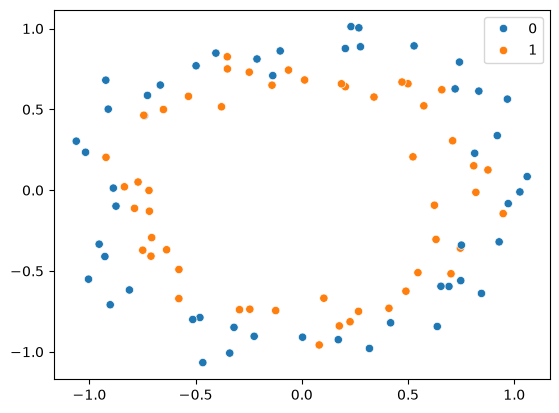

In [4]:
sns.scatterplot(x = x[:, 0], y = x[:, 1], hue=y)

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [6]:
model = Sequential()
model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1,activation = "sigmoid"))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

/workspaces/Deep-Learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1788932151.211611   80574 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=3500, verbose=0)

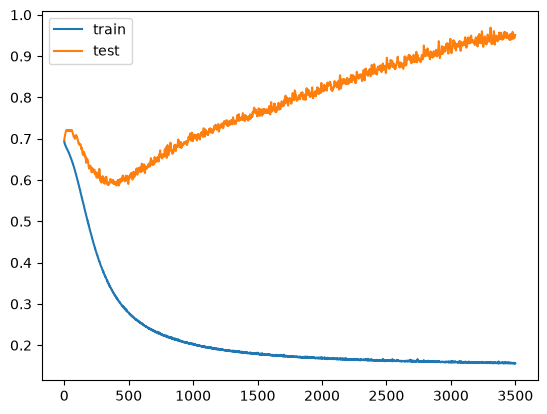

In [8]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

<h2>This is overfitting</h2>

In [9]:
y_prob = model.predict(x_test)
y_pred = (y_prob > 0.5).astype(int)
print(y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


[[1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]]


In [10]:
class KerasClassifier:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        y_prob = self.model.predict(X)
        return (y_prob > 0.5).astype(int).flatten()

In [11]:
model = KerasClassifier(model)

   1/9600 ━━━━━━━━━━━━━━━━━━━━ 11:00 69ms/step

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 853us/step


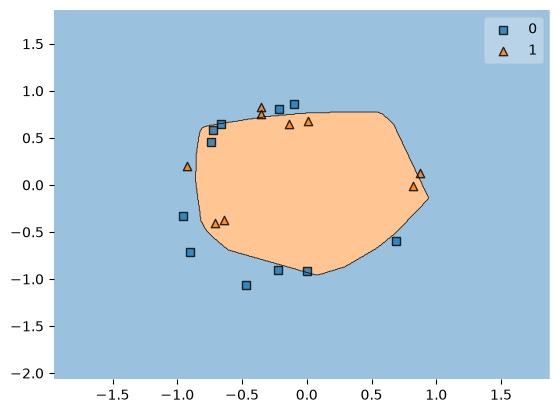

In [12]:
plot_decision_regions(x_test, y_test.ravel(), clf=model)
plt.show()

<h1>Early Stopping</h1>

In [32]:
model1 = Sequential()
model1.add(Dense(256, input_dim=2, activation='relu'))
model1.add(Dense(1,activation = "sigmoid"))

/workspaces/Deep-Learning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [30]:
classback = EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=100,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=False
)

In [34]:
history1 = model1.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=3500, verbose=0, callbacks= classback)

Epoch 514: early stopping


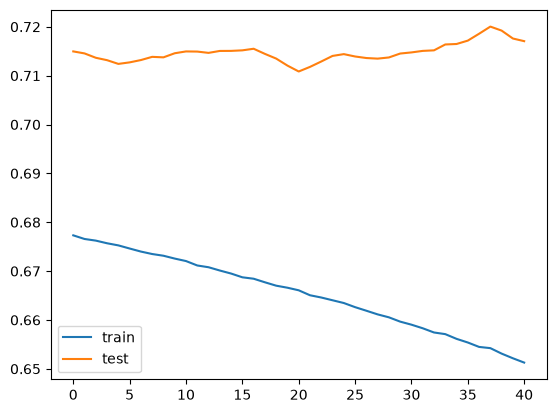

In [25]:
plt.plot(history1.history['loss'], label='train')
plt.plot(history1.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 9s 917us/step


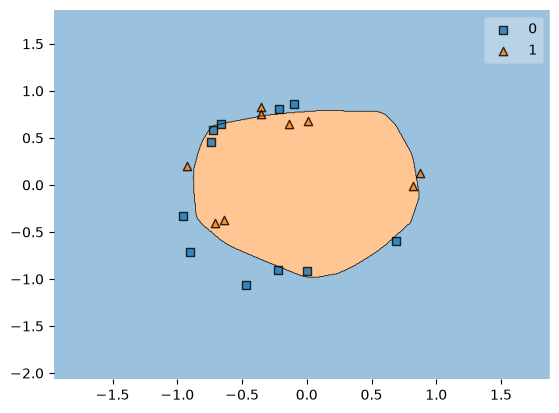

In [35]:
model1 = KerasClassifier(model1)
plot_decision_regions(x_test, y_test.ravel(), clf=model1)
plt.show()